# Домашняя работа "Сегментация и детекция объектов". Тян Е.В.

## Задание
Построить классификатор изображений рукописного ввода на базе MNIST. В качестве шаблона в данной работе можно использовать ipython-ноутбук 002-digit.ipynb.

Классификатор предлагается строить на признаках, полученных в результате предобработки изображений, например, гистограммы градиентов (HOG) или результат PCA преобразования.

В качестве модели классификатора можно использовать любую известную Вам модель, за исключением сверточных нейронных сетей.

Критерием качества классификатора является метрика accuracy. Для получения зачета по данной работе, значение метрики accuracy должно быть больше 0.6. Метрика оценивается на тестовой выборке в рамках контеста Digit Recognizer на Kaggle.

Решение необходимо предоставить в виде ipython-ноутбука с реализацией процесса построения модели и скриншота с финальным результатом на Kaggle.

## Импорт библиотек

In [119]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

%matplotlib inline

## Загрузка данных

In [120]:
train = np.loadtxt('./digit-recognizer/train.csv', delimiter=',', skiprows=1)
test = np.loadtxt('./digit-recognizer/test.csv', delimiter=',', skiprows=1)

label = train[:, 0].astype(np.int64)
train = train[:, 1:]

train_img = np.resize(train, (train.shape[0], 28, 28))
test_img = np.resize(test, (test.shape[0], 28, 28))

## Визуализируем данные

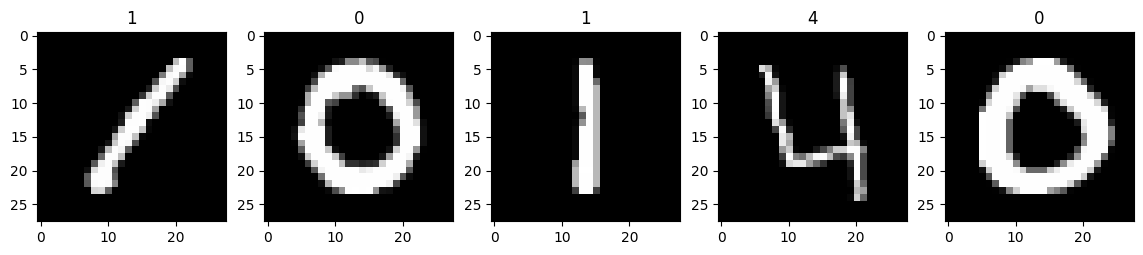

In [121]:
fig = plt.figure(figsize=(20, 10))
for i, img in enumerate(train_img[0:5], 1):
    subplot = fig.add_subplot(1, 7, i)
    plt.imshow(img, cmap='gray');
    subplot.set_title('%s' % label[i - 1]);

## План решения задачи
- Представим все изображения в тренировочной выборке в виде одномерного массива чисел;
- Выберем подмножество на котором будем вычислять главные компоненты (собственные ветора матрицы ковариации);
- Вычислим среднее значение на этом подмножестве и отцентрируем данные в нем;
- Вычислим матрицу ковариации и собственные вектора, анализ нужного количества компонент пропустим, сразу возьмем 32 вектора, полагаясь на результаты из практического занятия;
- Переведем все изображения в тренировочной выборке в пространство главных компонент (отцентрируем, умножим на матрицу опорных веторов);
- Обучим модель опорных векторов на тренировочной выборке;
- Переведем все изображения в тестовой выборке в пространство главных компонент (отцентрируем, умножим на матрицу опорных веторов);
- Классифицируем изображения из тестовой выборки с помощью обученногй модели;
- Визуализируем результат классификации;
- Сформируем файл ответов, отправим в www.kaggle.com.

## Решение
### Представим все изображения в тренировочной выборке в виде одномерного массива чисел;

In [122]:
train_img_flattened = train_img.reshape(-1, 28 * 28).astype(np.float32)

### Выберем подмножество на котором будем вычислять главные компоненты (собственные ветора матрицы ковариации)

In [123]:
choices = np.random.choice(train_img.shape[0], 10000)
pca_images = train_img_flattened[choices]

### Вычислим среднее значение на этом подмножестве и отцентрируем данные в нем

In [124]:
img_mean = pca_images.mean(axis=0)
pca_images -= img_mean

### Вычислим матрицу ковариации и собственные вектора

In [125]:
# матрица ковариации признаков
cov = np.dot(pca_images.T, pca_images) / pca_images.shape[0]
U, _, _ = np.linalg.svd(cov)
# анализ нужного количества компонент пропустим, сразу возьмем 32 вектора, полагаясь на результаты из практического занятия
U = U[:, :32]

### Переведем все изображения в тренировочной выборке в пространство главных компонент

In [126]:
X_train = train_img_flattened - img_mean
X_train = np.dot(X_train, U)
y_train = label

### Обучим модель опорных векторов на тренировочной выборке

In [127]:
from sklearn import svm
svm_model = svm.SVC()
svm_model.fit(X_train, y_train)

SVC()

### Переведем все изображения в тестовой выборке в пространство главных компонент

In [128]:
X_test = test - img_mean
X_test = np.dot(X_test, U)

### Классифицируем изображения из тестовой выборки с помощью обученногй модели

In [129]:
predictions = svm_model.predict(X_test)

### Визуализируем результат классификации

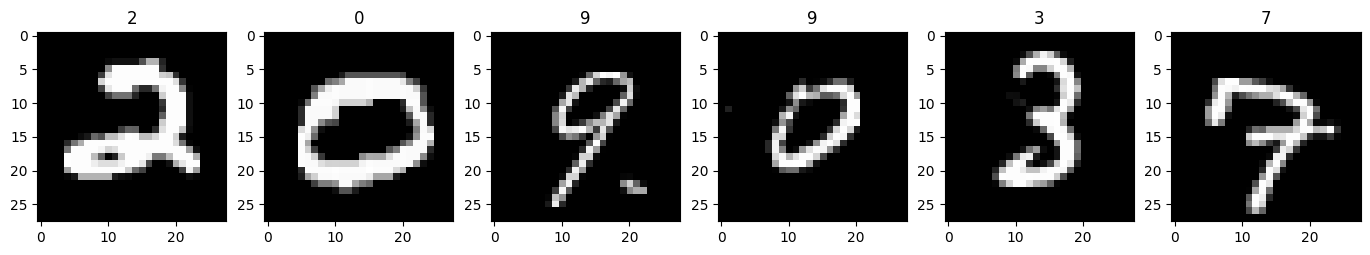

In [130]:
from matplotlib import pyplot as plt
fig = plt.figure(figsize=(20, 10))
for i, img in enumerate(test[0:6]):
    subplot = fig.add_subplot(1, 7, i+1)
    plt.title('%s' % predictions[i])
    plt.imshow(img.reshape((28,28)), cmap='gray')

### Сформируем файл ответов, отправим в www.kaggle.com

In [131]:
with open('./digit-recognizer/result.csv', 'w') as dst:
    dst.write('ImageId,Label\n')
    for i, p in enumerate(predictions, 1):
        dst.write('%s,%s\n' % (i, p))